<a href="https://colab.research.google.com/github/Rajeraghav/AI-Engineer-Journey/blob/main/Day06/Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Advertising.csv to Advertising.csv
FIRST FIVE RECORDS
   ID     TV  Radio  Newspaper  Sales
0   1  230.1   37.8       69.2   22.1
1   2   44.5   39.3       45.1   10.4
2   3   17.2   45.9       69.3    9.3
3   4  151.5   41.3       58.5   18.5
4   5  180.8   10.8       58.4   12.9

Dataset Shape: (200, 5)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing Values
ID           0
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistical Summary
               ID          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000 

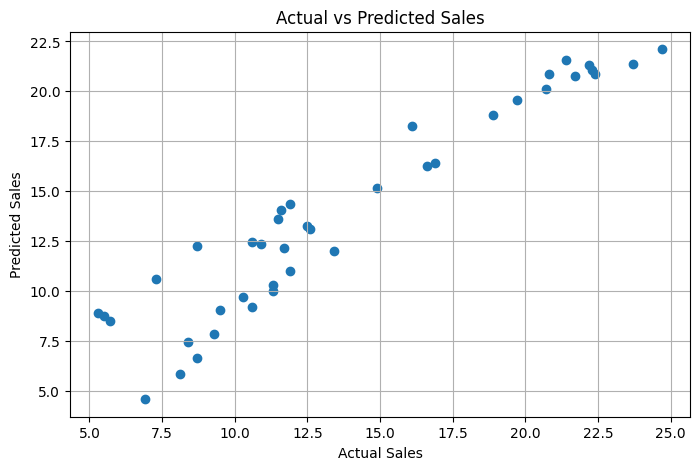


Feature Importance
     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


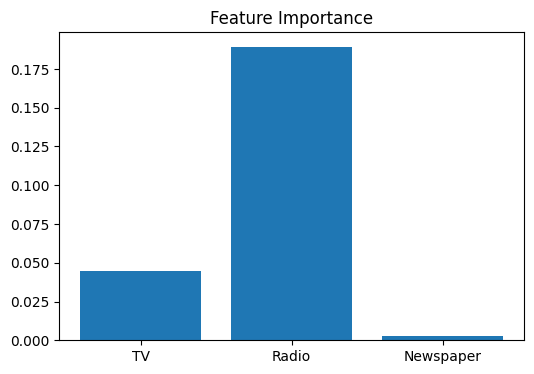


Output Saved Successfully


PROJECT SUMMARY
Dataset : Advertising.csv
Records : 200
MAE : 1.46
RMSE : 1.78
R2 Score : 0.9


In [1]:
# ==========================================================
# DAY06 - SALES FORECASTING
# Regression
# Author : Rajeswari P
# ==========================================================

# ==========================
# Step 1 : Upload Dataset
# ==========================

from google.colab import files

uploaded = files.upload()

import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# ==========================
# Step 2 : Import Libraries
# ==========================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================
# Step 3 : Data Exploration
# ==========================

print("="*60)
print("FIRST FIVE RECORDS")
print("="*60)

print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Info")

print(df.info())

print("\nMissing Values")

print(df.isnull().sum())

print("\nStatistical Summary")

print(df.describe())

# ==========================
# Step 4 : Features & Target
# ==========================

X = df[['TV','Radio','Newspaper']]

y = df['Sales']

# ==========================
# Step 5 : Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

# ==========================
# Step 6 : Train Model
# ==========================

model = LinearRegression()

model.fit(X_train,y_train)

predictions = model.predict(X_test)

# ==========================
# Step 7 : Evaluation
# ==========================

mae = mean_absolute_error(y_test,predictions)

mse = mean_squared_error(y_test,predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,predictions)

print("\nMAE :",mae)

print("MSE :",mse)

print("RMSE :",rmse)

print("R2 Score :",r2)

# ==========================
# Step 8 : Actual vs Predicted
# ==========================

plt.figure(figsize=(8,5))

plt.scatter(y_test,predictions)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.grid()

plt.show()

# ==========================
# Step 9 : Feature Importance
# ==========================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_

})

print("\nFeature Importance")

print(importance)

plt.figure(figsize=(6,4))

plt.bar(

    importance["Feature"],

    importance["Coefficient"]

)

plt.title("Feature Importance")

plt.show()

# ==========================
# Step 10 : Save Predictions
# ==========================

output = pd.DataFrame({

    "Actual Sales":y_test.values,

    "Predicted Sales":predictions

})

output.to_csv(

    "Sales_Forecasting_Output.csv",

    index=False

)

print("\nOutput Saved Successfully")

# ==========================
# Step 11 : Project Summary
# ==========================

print("\n")

print("="*60)

print("PROJECT SUMMARY")

print("="*60)

print("Dataset :",filename)

print("Records :",len(df))

print("MAE :",round(mae,2))

print("RMSE :",round(rmse,2))

print("R2 Score :",round(r2,2))

print("="*60)